# Quantization Aware Training + Knowledge Distillation using Export Model

In [1]:
import os
import time
import copy
import numpy as np
import logging
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader
from typing import Callable, Optional, Any

from src.utils import (load_data, process_callbacks, benchmark, compute_loss_and_predictions, calculate_metrics, 
                       plot_train_val_curve, test_inference)
from src.Quantization.quantization_utils.model_setup import qat_kd_setup
from src.Quantization.quantization_utils.conversions.litert import quantize_pytorch_model, convert_pytorch_model_to_tflite, check_quantized_modules
from src.Quantization.quantization_utils.conversions.onnx import export_pytorch_to_onnx, export_onnx_to_savedmodel, export_savedmodel_to_tflite
from src.train.knowledge_distillation import compute_distillation_loss
from src.utils.logging_setup import configure_logging

2025-04-22 20:17:37.284165: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-22 20:17:37.306492: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-22 20:17:37.306517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-22 20:17:37.307349: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-22 20:17:37.311778: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Training QAT + KD

In [3]:
def train_knowledge_distillation(
    teacher: nn.Module,
    student: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    learning_rate: float,
    epochs: int,
    criterion: Callable[[torch.Tensor, torch.Tensor], tuple[torch.Tensor, torch.Tensor, torch.Tensor]],
    optimizer: torch.optim.Optimizer,
    callbacks: list[Any],
    quant_mode: str,
    T: float,
    soft_target_loss_weight: float,
    ce_loss_weight: float,
    device: torch.device
) -> dict[str, list[float]]:
    """
    Trains the student model using knowledge distillation from the teacher model.
    
    The total loss is a weighted sum of:
      - The distillation loss computed as KL divergence between softened teacher and student logits.
      - The standard loss computed on true labels.
      
    During validation, the student model is switched to evaluation mode (and optionally quantized) 
    to simulate the behavior of the final quantized model. Training and validation metrics are logged 
    and stored per epoch.
    
    Parameters:
        teacher (nn.Module): The pre-trained teacher model.
        student (nn.Module): The student model to be trained.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        learning_rate (float): The learning rate used (for logging purposes).
        epochs (int): Number of training epochs.
        criterion (Callable): Loss function for true label loss (e.g., nn.CrossEntropyLoss). 
                              This function should return a tuple: (label_loss, probabilities, predictions).
        optimizer (torch.optim.Optimizer): Optimizer for updating the student model parameters.
        callbacks (list[Any]): List of callback objects with methods on_epoch_start and on_epoch_end.
        quant_mode (str): Quantization mode string (e.g., 'eager', 'fx', or 'export') used during validation.
        T (float): Temperature for softening the logits.
        soft_target_loss_weight (float): Weight for the distillation (soft target) loss.
        ce_loss_weight (float): Weight for the cross entropy loss computed on true labels.
        device (torch.device): Device to perform training on.
    
    Returns:
        dict[str, list[float]]: A dictionary containing training and validation loss history 
                                  with keys 'train' and 'val'.
    """
    loss_dict = {'train': [], 'val': []}
    # Set teacher to evaluation mode (its parameters won't be updated)
    teacher.eval()
    
    for epoch in range(epochs):
        logs = {"model": student, 
                "batch_size": train_loader.batch_size, 
                "learning_rate": learning_rate, 
                "optimizer": optimizer,
                "criterion": criterion,
                "epoch": epoch}

        # Trigger on_epoch_start callbacks
        for callback in callbacks:
            callback.on_epoch_start(epoch, logs)

        for phase in ['train', 'val']:
            is_train = phase == 'train'

            # For training phase, we use the original student model.
            # For validation, we create a deep copy and quantize it.
            if is_train:
                # current_student = student.to(device)
                # Ensure the model is in train mode
                torch.ao.quantization.move_exported_model_to_train(student)
            else:
                # Create a deep copy to avoid altering the training model
                # current_student = copy.deepcopy(student).to(device)
                # Quantize the copied student model for validation
                # Pass save_dir as None to avoid saving the state dict
                # current_student = quantize_pytorch_model(current_student, quant_mode=quant_mode, save_dir=None)
                # Switch to evaluation mode to perform inference
                torch.ao.quantization.move_exported_model_to_eval(student)

            data_loader = train_loader if is_train else val_loader

            running_loss = 0.0
            total_samples  = 0.0
            predictions, ground_truths, probabilities = [], [], []

            with tqdm(total=len(data_loader), desc=f"{phase.capitalize()} Epoch {epoch + 1}/{epochs}") as pbar:
                for inputs, labels in data_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    
                    # Zero gradients only during training
                    if is_train:
                        optimizer.zero_grad()
                    
                    # Teacher forward pass without gradient computation.
                    with torch.no_grad():
                        teacher = teacher.to(device)
                        teacher_logits = teacher(inputs)
                    
                    # Enable gradients only in training phase
                    with torch.set_grad_enabled(is_train):                        
                        student = student.to(device)
                        student_logits = student(inputs)

                        # Compute soft targets loss using KL divergence.
                        soft_loss = compute_distillation_loss(teacher_logits=teacher_logits, student_logits=student_logits, T=T)

                        # Compute the true label loss and obtain predictions/probabilities
                        label_loss, probs, preds = compute_loss_and_predictions(student_logits, labels, criterion)
                        
                        # Combine the losses using the specified weights.
                        loss = soft_target_loss_weight * soft_loss + ce_loss_weight * label_loss

                        # Backpropagate and update weights if in training mode.
                        if is_train:
                            loss.backward()
                            optimizer.step()
                    
                    # Update running loss and sample count
                    batch_size = inputs.size(0)
                    running_loss += loss.item() * batch_size
                    total_samples += batch_size

                    # Accumulate predictions and ground truths for metrics
                    ground_truths.extend(labels.cpu().detach().numpy())
                    predictions.extend(preds.cpu().detach().numpy())
                    probabilities.extend(probs.cpu().detach().numpy())
                    
                    # Update progress bar with average loss so far
                    pbar.set_postfix(loss=f"{running_loss / total_samples:.4f}")
                    pbar.update(1)
                
            # Compute aggregated metrics after epoch
            epoch_loss = running_loss / total_samples
            
            y_true = np.array(ground_truths)
            y_pred = np.array(predictions)
            y_proba = np.array(probabilities) if probabilities else None

            # Calculate metrics
            metrics = calculate_metrics(y_true, y_pred, y_proba)

            loss_dict[phase].append(epoch_loss)
            logging.info(f"{phase.capitalize()} Loss: {epoch_loss:.4f}")
            logging.info(f"{phase.capitalize()} Metrics: " + ", ".join([f"{key}: {value:.4g}" for key, value in metrics.items()]))
            logs.update({f"{phase}_loss": epoch_loss, **metrics})

        # Trigger on_epoch_end callbacks
        for callback in callbacks:
            callback.on_epoch_end(epoch, logs)

        # Check for early stopping
        if any(getattr(cb, "early_stop", False) for cb in callbacks):
            break

    return loss_dict

### Training Loop

In [4]:
def train_qat_kd(
    teacher_name: str,
    student_name: str,
    data_loaders: dict[str, DataLoader],
    save_dir: str,
    learning_rate: float = 0.001,
    epochs: int = 5,
    criterion: str = "cross_entropy",
    optimizer: str = "adam",
    callbacks: Optional[list[Any]] = None,
    teacher_model_weights: Optional[str] = None,
    quant_mode: str = "export",
    config: str = "qnnpack",
    class_weights: bool = False,
    device: torch.device = torch.device("cuda")
) -> tuple[nn.Module, nn.Module]:
    """
    Trains a student model using Knowledge Distillation (KD) combined with Quantization-Aware Training (QAT).
    
    This function performs the following steps:
      1. Loads the teacher and student models using their respective model names. The student model is loaded
         as a standard model and then prepared for QAT via quantization_mode.
      2. Configures the loss function and optimizer using helper functions.
      3. Runs the training loop for a specified number of epochs while applying knowledge distillation 
         (combining soft targets from the teacher with the true label loss).
      4. During training, checkpoints and callbacks are handled. After training, the best model weights 
         are loaded and the student model is quantized for export.
      5. If a test DataLoader is provided, the quantized student model is evaluated.
    
    Parameters:
        teacher_name (str): Name of the pre-trained teacher model (e.g., 'resnet50', 'efficientnet_b0').
        student_name (str): Name of the student model to be trained with QAT.
        data_loaders (dict[str, DataLoader]): Dictionary containing DataLoaders for dataset splits 
                                              (keys: 'train', 'val', and optionally 'test').
        save_dir (str): Directory where the trained model, checkpoints, and metrics will be saved.
        learning_rate (float, optional): Learning rate for the optimizer. Defaults to 0.001.
        epochs (int, optional): Number of training epochs. Defaults to 5.
        criterion (str, optional): Loss function name (e.g., 'cross_entropy', 'bce'). Defaults to 'cross_entropy'.
        optimizer (str, optional): Optimizer name (e.g., 'adam', 'sgd'). Defaults to 'adam'.
        callbacks (Optional[list[Any]], optional): List of callback objects for monitoring, checkpointing,
                                                     and early stopping. Defaults to None.
        teacher_model_weights (Optional[str], optional): Path to pre-trained weights for the teacher model.
                                                         Defaults to None.
        quant_mode (str, optional): Quantization mode to use for preparing the student model 
                                    ('eager', 'fx', or 'export'). Defaults to 'export'.
        config (str, optional): QAT configuration identifier ('qnnpack' for default QAT config for qnnpack 
                                or custom). Defaults to 'qnnpack'.
        class_weights (bool, optional): Whether to compute and apply class weights for imbalanced datasets.
                                        Defaults to False.
        device (torch.device, optional): Device to perform operations on. Defaults to torch.device("cuda").
    
    Returns:
        tuple[nn.Module, nn.Module]: A tuple containing:
            - teacher_model: The loaded teacher model.
            - quantized_student: The quantized student model after training.
    
    Notes:
        - The student model is prepared for QAT using example inputs from the training DataLoader.
        - After training, the best model weights are loaded from a checkpoint, and the student model is quantized 
          (using quantize_pytorch_model) for export.
        - Training metrics (loss curves and evaluation metrics) are saved to the specified directory.
    """
    # Load dataset
    logging.info("Loading datasets...")
    train_loader = data_loaders["train"]
    val_loader = data_loaders["val"]
    logging.info("Datasets loaded successfully.")
    
    # Set up teacher and student models, loss function, and optimizer.
    teacher, student, criterion_fn, optimizer_obj = qat_kd_setup(teacher=teacher_name, 
                                                                student=student_name,
                                                                learning_rate=learning_rate, 
                                                                criterion=criterion, 
                                                                optimizer=optimizer, 
                                                                teacher_model_weights=teacher_model_weights, 
                                                                dataloader=train_loader, 
                                                                quant_mode=quant_mode,
                                                                config=config,
                                                                class_weights=class_weights,
                                                                device=torch.device("cpu"))
    logging.info("Model setup complete.")

    # Set up checkpoint and metrics directories.
    quantized_model_path = os.path.join(save_dir, f"{student_name}_qat_kd.pth")
    metrics_save_dir = os.path.join(save_dir, "metrics")
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(metrics_save_dir, exist_ok=True)
    logging.info(f"Checkpoints and metrics will be saved to: {save_dir}")

    # Trigger training start callbacks.
    if callbacks is not None:
        for callback in callbacks:
            callback.on_train_start(logs={})

    # Training loop
    logging.info("Starting training...")
    start_time = time.time()

    # Train the student model using knowledge distillation.
    loss_dict = train_knowledge_distillation(
                            teacher=teacher, 
                            student=student, 
                            train_loader=train_loader,
                            val_loader=val_loader,
                            learning_rate=learning_rate,
                            epochs=epochs, 
                            criterion=criterion_fn,
                            optimizer=optimizer_obj,
                            callbacks=callbacks,
                            quant_mode=quant_mode,
                            T=2, 
                            soft_target_loss_weight=0.25, 
                            ce_loss_weight=0.75, 
                            device=device
                        )
    elapsed_time = time.time() - start_time
    logging.info(f"Training complete in {elapsed_time // 60:.0f}m {elapsed_time % 60:.0f}s")

    # Trigger training end callbacks.
    if callbacks is not None:
        for callback in callbacks:
            callback.on_train_end(logs={"model": student, "optimizer": optimizer_obj})

    # Load the best student model weights from checkpoint.
    model_data = torch.load(quantized_model_path, weights_only=True)
    student.load_state_dict(model_data)
    logging.info(f"Best model weights loaded from: {quantized_model_path}")


    # Quantize the student model for export.
    quantized_student = quantize_pytorch_model(student.to("cpu"), quant_mode, save_dir=os.path.join(save_dir, "quantized_state.pth"))
    # Plot training and validation loss curves.
    plot_train_val_curve(loss_dict, save_path=os.path.join(metrics_save_dir, "loss_curve.png"))

    # If a test set is provided, perform inference evaluation on the quantized student model.
    if "test" in data_loaders and data_loaders["test"] is not None:
        test_inference(quantized_student, data_loaders["test"], torch.device("cpu"), save_dir=metrics_save_dir)

    return teacher, quantized_student

### Hyperparameters

[INFO 2025-04-22 20:17:38,061 preprocessing.py:17] Train dataset size: 29322
[INFO 2025-04-22 20:17:38,062 preprocessing.py:26] Class distribution for train dataset:
[INFO 2025-04-22 20:17:38,063 preprocessing.py:28]   Class 'Actinic keratoses': 693 samples
[INFO 2025-04-22 20:17:38,063 preprocessing.py:28]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-04-22 20:17:38,063 preprocessing.py:28]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-04-22 20:17:38,063 preprocessing.py:28]   Class 'Chickenpox': 900 samples
[INFO 2025-04-22 20:17:38,063 preprocessing.py:28]   Class 'Cowpox': 792 samples
[INFO 2025-04-22 20:17:38,063 preprocessing.py:28]   Class 'Dermatofibroma': 191 samples
[INFO 2025-04-22 20:17:38,064 preprocessing.py:28]   Class 'HFMD': 1932 samples
[INFO 2025-04-22 20:17:38,064 preprocessing.py:28]   Class 'Healthy': 1368 samples
[INFO 2025-04-22 20:17:38,064 preprocessing.py:28]   Class 'Measles': 660 samples
[INFO 2025-04-22 20:17:38,064 preprocessi

Model prepared using Export Mode QAT.


Train Epoch 1/1: 100%|██████████| 917/917 [03:02<00:00,  5.02it/s, loss=0.8380]
[INFO 2025-04-22 20:20:44,793 843714288.py:146] Train Loss: 0.8380
[INFO 2025-04-22 20:20:44,794 843714288.py:147] Train Metrics: Accuracy: 0.6985, Recall: 0.5026, Precision: 0.585, F1-Score: 0.5238, AUC-Score: 0.942
Val Epoch 1/1: 100%|██████████| 115/115 [00:19<00:00,  5.97it/s, loss=0.6646]
/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[INFO 2025-04-22 20:21:04,348 843714288.py:146] Val Loss: 0.6646
[INFO 2025-04-22 20:21:04,348 843714288.py:147] Val Metrics: Accuracy: 0.7634, Recall: 0.6417, Precision: 0.6862, F1-Score: 0.6477, AUC-Score: 0.9679
[INFO 2025-04-22 20:21:04,517 2654890307.py:117] Training comp

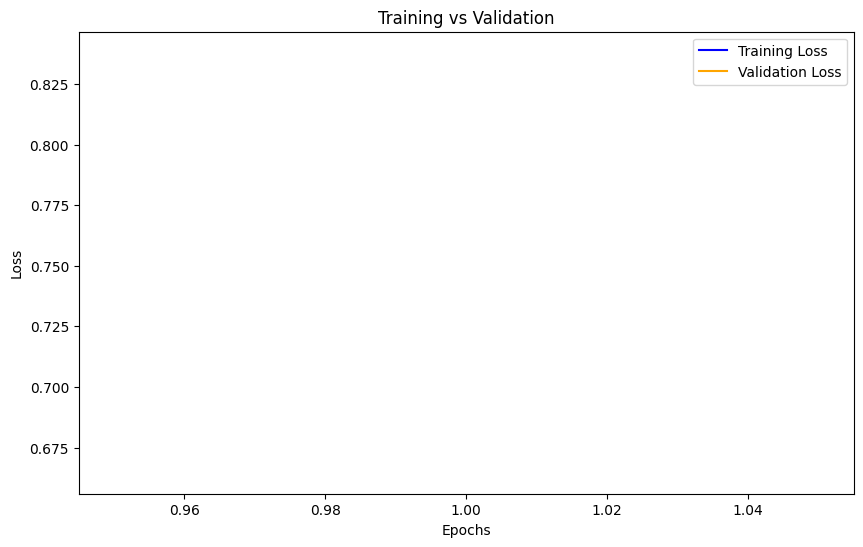

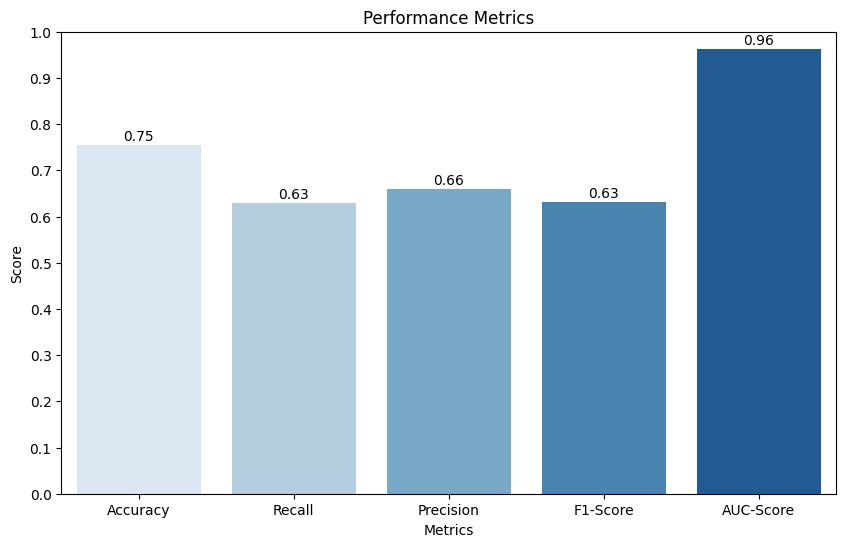

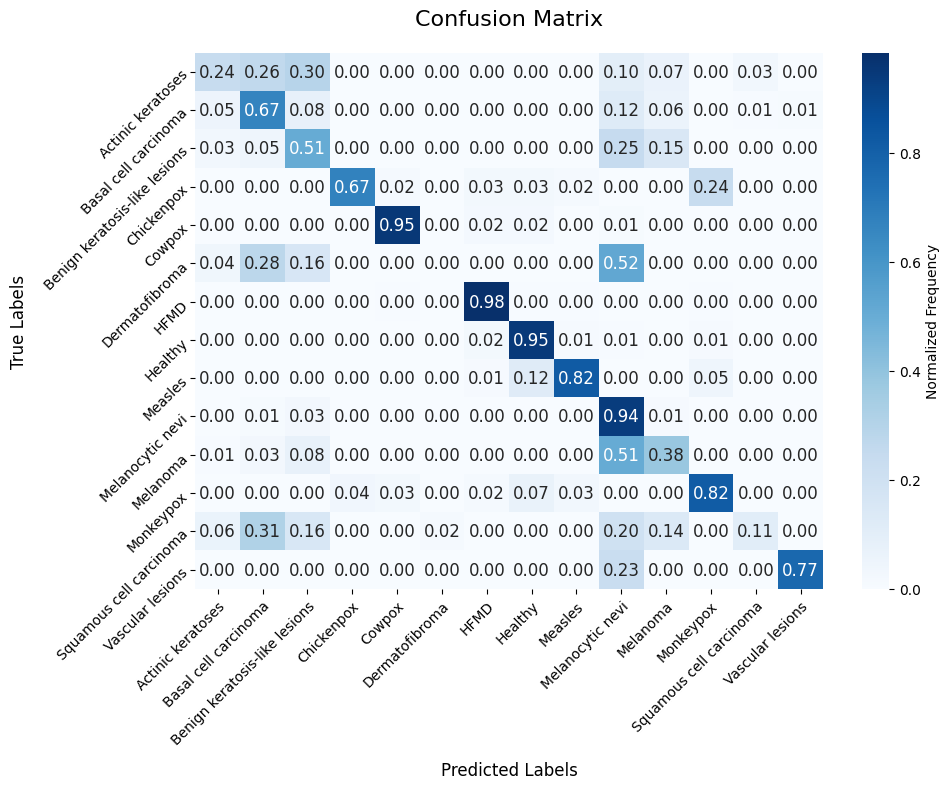

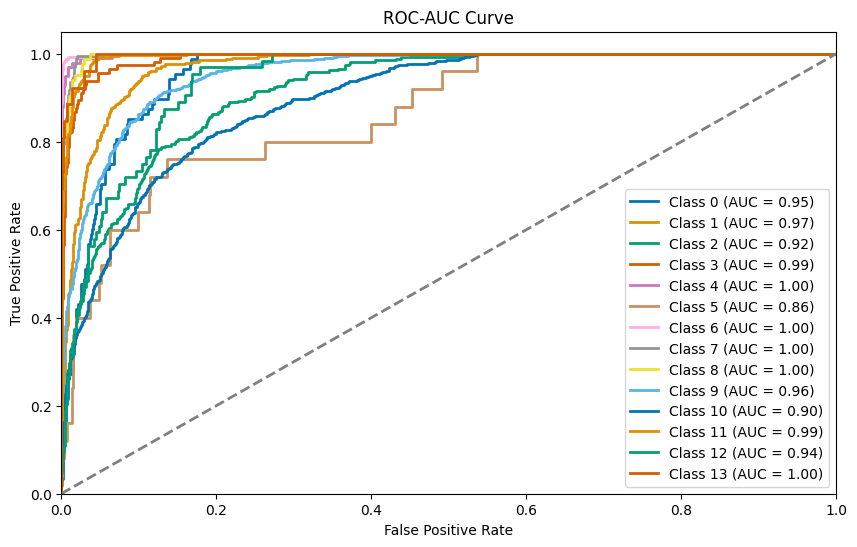

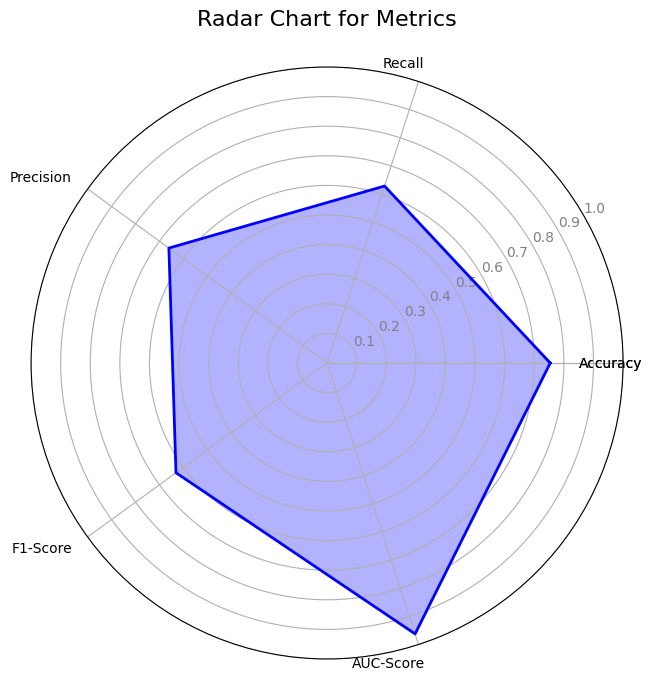

In [5]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"
# Before any quantization setup
# torch.backends.quantized.engine = 'qnnpack'
# TODO: Organize repo
teacher, quantized_student = train_qat_kd(
                                        teacher_name=teacher_model, 
                                        student_name=student_model,
                                        data_loaders=dataloaders,
                                        save_dir=save_dir,
                                        learning_rate=learning_rate,
                                        epochs=epochs,
                                        criterion = criterion,
                                        optimizer = optimizer,
                                        callbacks=CALLBACKS,
                                        quant_mode="export",
                                        teacher_model_weights=teacher_model_weights,
                                        device=device,
                                )


In [6]:
# from src.utils.model_setup import setup_model
# from src.Quantization.quantization_utils.model_setup import quantization_mode

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# pretrained_weights = f"models/SkinCancer/Quantized/mobilenet_v2_qat_kd.pth"
# batch_size = 32
# dataloaders = load_data(dataset="SkinCancer", batch_size=batch_size)
# num_classes = len(dataloaders["train"].dataset.classes)
# model = setup_model(model_name="mobilenet_v2", pretrained_weights=None, num_classes=num_classes)

# example_inputs = next(iter(dataloaders["train"]))[0].to("cpu")

# student_model = quantization_mode(model, "export", example_inputs=(example_inputs,)).to(device)

# # Now load the state dict.
# state_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")
# student_model.load_state_dict(state_dict)

# quantized_student = quantize_pytorch_model(student_model, "export", None)


In [7]:
# dataset = "SkinCancer"
# batch_size = 32
# learning_rate = 0.001
# epochs = 1
# save_dir = f"models/{dataset}/Quantized"
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# teacher_model = "mobilenet_v2"
# student_model = "mobilenet_v2"
# dataloaders = load_data(dataset=dataset, batch_size=batch_size)
# criterion = "cross_entropy"
# optimizer = "adam"
# teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

# quantized_student, student, criterion_fn, optimizer_obj = qat_kd_setup(teacher=teacher_model, 
#                                                             student=student_model,
#                                                             learning_rate=learning_rate, 
#                                                             criterion=criterion, 
#                                                             optimizer=optimizer, 
#                                                             teacher_model_weights=teacher_model_weights, 
#                                                             dataloader=dataloaders['train'], 
#                                                             quant_mode="export",
#                                                             config="qnnpack",
#                                                             class_weights=False,
#                                                             device=torch.device("cpu"))

In [8]:
from src.Quantization.quantization_utils.conversions.litert import is_quantized_model

def export_pytorch_to_onnx(model: torch.nn.Module, example_input: torch.Tensor, onnx_file_path: str, opset_version: int = 18) -> None:
    """
    Exports a given PyTorch model to the ONNX format.

    This function uses torch.onnx.export to convert the model to ONNX. It assumes the model is in eval mode.
    Note that quantized models may face compatibility issues with ONNX; ensure that the opset_version and model
    configuration are supported.

    Args:
        model (torch.nn.Module): The PyTorch model to export.
        example_input (torch.Tensor): An example input tensor with the appropriate shape.
        onnx_file_path (str): Path where the ONNX file will be saved.
        opset_version (int): ONNX opset version to use. Defaults to 18.
    """

    # Set model to evaluation mode.
    if is_quantized_model(model):
        torch.ao.quantization.allow_exported_model_train_eval(model)  # restores eval/train to call move_exported_model_* under the hood
    
    model.eval()

    # Export the model.
    torch.onnx.export(
        model,                          # model being exported
        example_input,                  # example input to the model
        onnx_file_path,                 # where to save the ONNX model
        export_params=True,             # store the trained parameter weights inside the model file
        opset_version=opset_version,    # specify the ONNX version to export the model to
        do_constant_folding=True,       # execute constant folding for optimization
        input_names=['input'],          # the model's input names
        output_names=['output'],        # the model's output names
        # dynamic_shapes={"input":  {0: torch.export.Dim("batch_size")}, "output": {0: torch.export.Dim("batch_size")}},  # enable dynamic batch size
        dynamic_axes={
            "input": {0: "batch_size"},   # use dynamic_axes instead of dynamic_shapes
            "output": {0: "batch_size"},
        },
        dynamo=False,
        external_data=False
        # fallback=True,                  # logs when TorchScript fallback occurs
        # report=True                     # generates a markdown report of the export
    )
    logging.info(f"Exported PyTorch model to ONNX at: {onnx_file_path}")



In [ ]:
example_inputs = next(iter(dataloaders['train']))[0]
onnx_file_path = f"models/SkinCancer/Quantized/{student_model}_qat_kd.onnx"
export_pytorch_to_onnx(model=quantized_student, example_input=example_inputs, onnx_file_path=onnx_file_path, opset_version=18)

In [ ]:
print("qat_kd: ", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.onnx") / 1e6)
# print("qat_kd: ", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.onnx.data") / 1e6)

qat_kd:  8.940011


In [7]:
student_model = "mobilenet_v2"
onnx_file_path = f"models/SkinCancer/Quantized/{student_model}_qat_kd.onnx"
export_onnx_to_savedmodel(onnx_file_path, saved_model_dir=f"models/SkinCancer/Quantized/{student_model}_qat_kd")

/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
2025-04-22 19:43:03.610830: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-22 19:43:03.611052: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node 

INFO:tensorflow:Assets written to: models/SkinCancer/Quantized/mobilenet_v2_qat_kd/assets


INFO:tensorflow:Assets written to: models/SkinCancer/Quantized/mobilenet_v2_qat_kd/assets


In [8]:
savedmodel_path=f"models/SkinCancer/Quantized/{student_model}_qat_kd"
export_savedmodel_to_tflite(saved_model_dir=savedmodel_path, tflite_model_path=f"models/SkinCancer/Quantized/{student_model}_qat_kd.tflite", 
                            calibration_dataloader=dataloaders['test'])

2025-04-22 19:52:16.571406: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2025-04-22 19:52:16.571436: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2025-04-22 19:52:16.571757: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: models/SkinCancer/Quantized/mobilenet_v2_qat_kd
2025-04-22 19:52:16.573745: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2025-04-22 19:52:16.573754: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: models/SkinCancer/Quantized/mobilenet_v2_qat_kd
2025-04-22 19:52:16.577710: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2025-04-22 19:52:16.578706: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2025-04-22 19:52:16.603906: I tensorflow/cc/saved_model/loader.cc:217] Running initializa

In [10]:
print("qat_kd: ", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.tflite") / 1e6)

qat_kd:  2.730944


In [ ]:
# TODO: Try a different model from mobilenetv2
# TODO: Try post-training quantization
# TODO: Try mapping weights manually from PyTorch -> Tensorflow

In [ ]:
benchmark(model1=teacher.to("cpu"), model2=quantized_student.to("cpu"), dataloader=dataloaders["test"], device=torch.device("cpu"))

### Final Quantization for model (Turn Fake-Quant tensors into real quant tensors)

In [ ]:
quant_copy = copy.deepcopy(quantized_student).to("cpu")

In [ ]:
print(quant_copy)

In [ ]:
quant_copy.print_readable()

In [ ]:
check_quantized_modules(quant_copy)

In [ ]:
quant_copy.eval()

In [ ]:
example_inputs = next(iter(dataloaders["train"]))[0].to("cpu")
torch.ao.quantization.move_exported_model_to_eval(quantized_student)
convert_pytorch_model_to_tflite(quantized_student, os.path.join(save_dir, f"{student_model}.tflite"), (example_inputs,))

In [ ]:
print("qat_kd: ", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.pth") / 1e6)
print("quantized_state: ", os.path.getsize("models/SkinCancer/Quantized/quantized_state.pth") / 1e6)
print("TFlite:", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2.tflite") / 1e6)

In [ ]:
print(quantized_student)

In [ ]:
quantized_student.print_readable()

In [ ]:
print(quantized_student.graph)